Exploratory Data Analysis (EDA)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('/content/Lab_Exam_binary_classification_dataset.csv')

df.head()

,Feature1,Feature2,Target
0,1.7250,520,Yes
1,1.8875,428,No
2,1.6000,552,Yes
3,1.4250,500,No
4,1.7750,628,No


In [2]:
# Info
print(df.info())

# Summary stats
print(df.describe())

# Check missing values
print("\nMissing values:\n", df.isnull().sum())

# Check duplicates
print("\nDuplicate rows:", df.duplicated().sum())

# Data types (IMPORTANT)
print("\nData types:\n", df.dtypes)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Feature1  1020 non-null   float64
 1   Feature2  1020 non-null   int64  
 2   Target    1000 non-null   object 
dtypes: float64(1), int64(1), object(1)
memory usage: 24.0+ KB
None
           Feature1     Feature2
count   1020.000000  1020.000000
mean      11.436679   520.988235
std      313.061049    69.793442
min        1.250000   400.000000
25%        1.450000   464.000000
50%        1.637500   520.000000
75%        1.828125   584.000000
max    10000.000000   640.000000

Missing values:
 Feature1     0
Feature2     0
Target      20
dtype: int64

Duplicate rows: 102

Data types:
 Feature1    float64
Feature2      int64
Target       object
dtype: object


In [3]:
# Remove missing values
df = df.dropna()

# Remove duplicates
df = df.drop_duplicates()

In [4]:
# Convert Yes/No to 1/0
df = df.replace({'Yes': 1, 'No': 0})

# Convert remaining categorical columns
df = pd.get_dummies(df, drop_first=True)

/tmp/ipykernel_5866/3240572122.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({'Yes': 1, 'No': 0})


Visualization

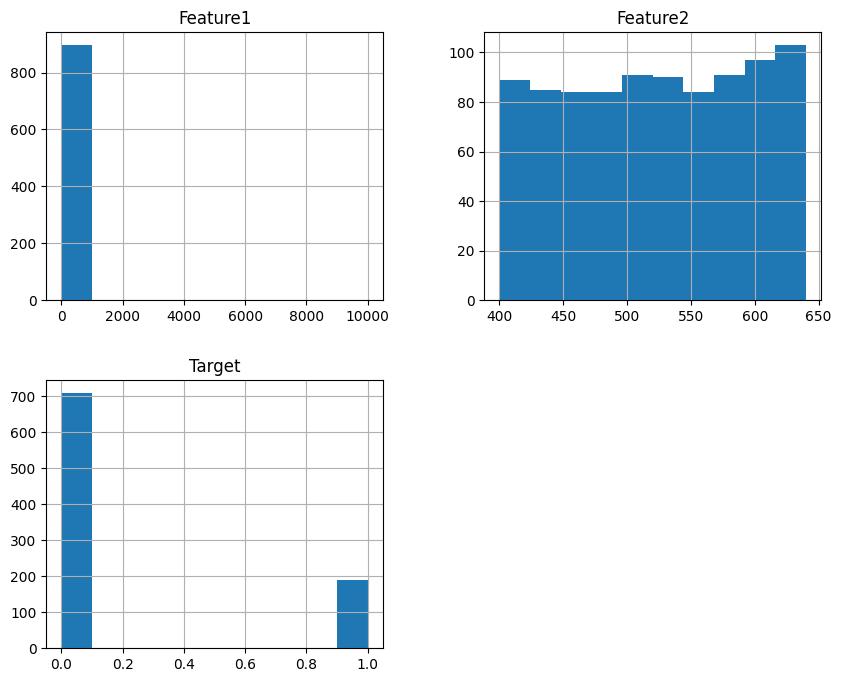

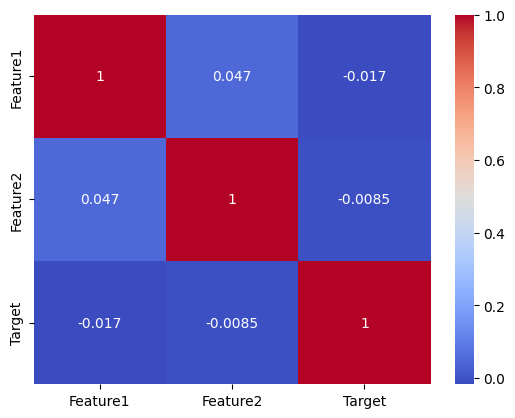

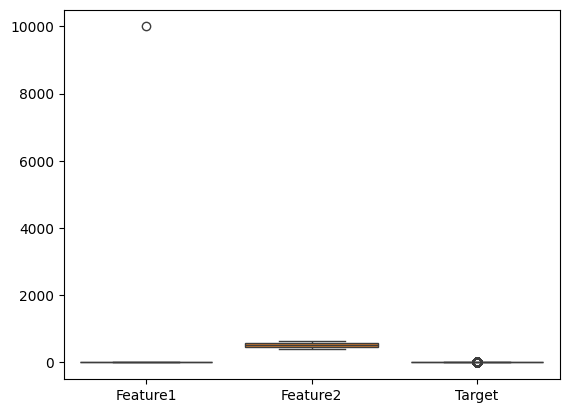

In [5]:
# Histogram
df.hist(figsize=(10,8))
plt.show()

# Correlation heatmap (NOW WORKS)
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

# Boxplot (outliers)
sns.boxplot(data=df)
plt.show()

Build Classification Model

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Features & target
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Model (fix convergence error)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

Decision Boundary

In [ ]:
# Use only first 2 features
X2 = X.iloc[:, :2].values
y2 = y.values

# Ensure target is numeric (FIX)
if y2.dtype == 'object':
    y2 = pd.factorize(y2)[0]

# Train model on same 2 features (IMPORTANT FIX)
model.fit(X2, y2)

# Meshgrid
x_min, x_max = X2[:, 0].min() - 1, X2[:, 0].max() + 1
y_min, y_max = X2[:, 1].min() - 1, X2[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Predict
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X2[:, 0], X2[:, 1], c=y2)

plt.title("Decision Boundary")
plt.xlabel(df.columns[0])
plt.ylabel(df.columns[1])
plt.show()

Model Evaluation